In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt


In [35]:

# --- [하이퍼파라미터 설정] ---

HIDDEN_NODES = 128
LR = 0.1
BATCH_SIZE = 100
EPOCHS = 20
ACTIVATION = 'relu'


In [36]:

# --- [데이터 준비] ---
transform = transforms.Compose([transforms.ToTensor()])
full_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)


In [37]:

# Train(5만) / Validation(1만) 분리
train_dataset, val_dataset = random_split(full_train, [50000, 10000])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [38]:

# --- [모델 설계] ---
class MNIST_Net(nn.Module):
    def __init__(self, hidden_size, act_type):
        super(MNIST_Net, self).__init__()
        self.fc1 = nn.Linear(784, hidden_size) # 입력층 784 -> 은닉층
        self.fc2 = nn.Linear(hidden_size, 10)  # 은닉층 -> 출력층 10
        self.activation = nn.ReLU() if act_type == 'relu' else nn.Sigmoid()

    def forward(self, x):
        x= x.view(-1,784)
        x = self.activation(self.fc1(x))
        return self.fc2(x) # CrossEntropyLoss가 Softmax를 포함함

model = MNIST_Net(HIDDEN_NODES, ACTIVATION)
criterion = nn.CrossEntropyLoss() # 손실함수 crossentropyloss
optimizer = optim.SGD(model.parameters(), lr=LR) # 옵티마이저 sgd


In [39]:

# 기록용 리스트
train_losses = []
val_accuracies = []
train_accuracies = []


# --- [학습 루프] ---
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    train_acc =0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _,predicted=torch.max(outputs.data,1)
        train_acc += (predicted == labels).sum().item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    avg_train_acc=100*train_acc/len(train_dataset)
    train_accuracies.append(avg_train_acc)
    # Validation
    model.eval()
    correct = 0
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / len(val_dataset)
    val_accuracies.append(val_acc)


    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {avg_loss:.4f}, Train Acc: {avg_train_acc:.2f}%, Val Acc: {val_acc:.2f}%")



Epoch [1/20] Loss: 0.5608, Train Acc: 85.75%, Val Acc: 90.67%
Epoch [2/20] Loss: 0.2838, Train Acc: 91.90%, Val Acc: 92.55%
Epoch [3/20] Loss: 0.2312, Train Acc: 93.40%, Val Acc: 93.84%
Epoch [4/20] Loss: 0.1957, Train Acc: 94.41%, Val Acc: 94.26%
Epoch [5/20] Loss: 0.1693, Train Acc: 95.21%, Val Acc: 94.97%
Epoch [6/20] Loss: 0.1493, Train Acc: 95.78%, Val Acc: 95.38%
Epoch [7/20] Loss: 0.1333, Train Acc: 96.21%, Val Acc: 95.69%
Epoch [8/20] Loss: 0.1201, Train Acc: 96.58%, Val Acc: 95.68%
Epoch [9/20] Loss: 0.1095, Train Acc: 96.94%, Val Acc: 96.31%
Epoch [10/20] Loss: 0.1004, Train Acc: 97.22%, Val Acc: 96.35%
Epoch [11/20] Loss: 0.0928, Train Acc: 97.37%, Val Acc: 96.45%
Epoch [12/20] Loss: 0.0861, Train Acc: 97.59%, Val Acc: 96.69%
Epoch [13/20] Loss: 0.0803, Train Acc: 97.81%, Val Acc: 96.77%
Epoch [14/20] Loss: 0.0744, Train Acc: 97.97%, Val Acc: 96.94%
Epoch [15/20] Loss: 0.0698, Train Acc: 98.10%, Val Acc: 96.95%
Epoch [16/20] Loss: 0.0658, Train Acc: 98.18%, Val Acc: 97.09%
E

In [40]:
# --- [최종 Test Accuracy] --- [cite: 40]
model.eval()
correct = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()
print(f"\n최종 Test Accuracy: {100 * correct / len(test_dataset):.2f}%")


최종 Test Accuracy: 97.44%


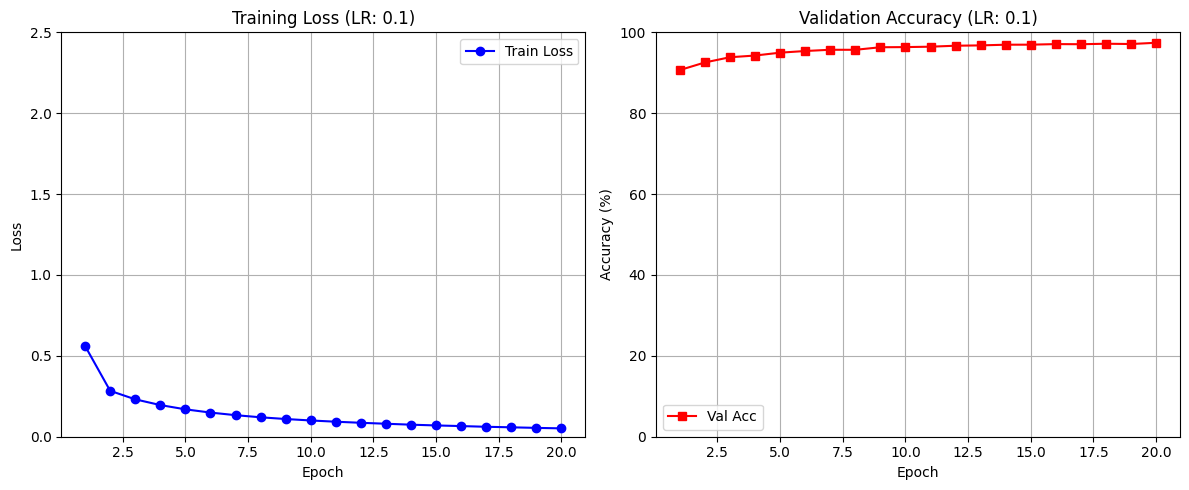

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# --- 왼쪽: Training Loss 그래프 (0 ~ 2.5 범위 고정) ---
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), train_losses, marker='o', color='blue', label='Train Loss')
plt.title(f'Training Loss (LR: {LR})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0, 2.5) # <--- Loss 축 범위 고정 (MNIST 기준 보통 2.3 내외에서 시작함)
plt.grid(True)
plt.legend()

# --- 오른쪽: Validation Accuracy 그래프 (0 ~ 100 범위 고정) ---
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), val_accuracies, marker='s', color='red', label='Val Acc')
plt.title(f'Validation Accuracy (LR: {LR})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100) # <--- Accuracy 축 범위를 0~100으로 고정!
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()